In [1]:
import torch
import cv2
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
from torchvision.ops import box_iou
from sklearn.metrics import jaccard_score
import os 

In [2]:
# Load YOLO model (Replace with your model path)
yolo_model = YOLO("/home/selc-a4-sr2/yolo_v12/yolov12/runs/detect/train4/weights/best.pt")
yolo_model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [3]:
# Load SAM model (Replace with your model path)
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

In [4]:
y_pred = yolo_model.predict("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg")
y_pred


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg: 1024x1024 62 0s, 8.5ms
Speed: 6.9ms preprocess, 8.5ms inference, 90.7ms postprocess per image at shape (1, 3, 1024, 1024)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0'}
 obb: None
 orig_img: array([[[109, 112, 110],
         [105, 108, 106],
         [107, 110, 108],
         ...,
         [107, 110, 108],
         [ 91,  93,  93],
         [ 70,  72,  72]],
 
        [[ 78,  81,  79],
         [ 65,  68,  66],
         [ 52,  55,  53],
         ...,
         [116, 119, 117],
         [ 92,  94,  94],
         [ 81,  83,  83]],
 
        [[ 72,  73,  71],
         [ 64,  65,  63],
         [124, 125, 123],
         ...,
         [ 69,  72,  70],
         [114, 116, 116],
         [ 77,  79,  79]],
 
        ...,
 
        [[105, 109,  97],
         [108, 112, 100],
         [111, 115, 103],
         ...,
         [132, 137, 128],
         [131, 136, 127],
         [131, 136, 127]],
 
        [[108, 112, 100],
         [108, 112, 100],
         [108, 112, 100],
         ...,
         [138, 142, 136

In [5]:
# Get bounding boxes
boxes = y_pred[0].boxes.xyxy  # (x1, y1, x2, y2) format
print("Bounding Boxes:", boxes)

# Get class IDs
class_ids = y_pred[0].boxes.cls
print("Class IDs:", class_ids)

# Get confidence scores
confidences = y_pred[0].boxes.conf
print("Confidence Score:", confidences)

# Get class names
class_names = [y_pred[0].names[int(cls)] for cls in class_ids]
print("Detected Classes:", class_names)

Bounding Boxes: tensor([[2.9535e-01, 3.3639e+02, 2.0264e+02, 5.2349e+02],
        [8.7885e+02, 4.5048e+02, 9.3680e+02, 5.3433e+02],
        [3.4395e+02, 5.1258e+02, 4.2676e+02, 5.9777e+02],
        [9.1792e+02, 4.0255e+02, 9.6094e+02, 4.4230e+02],
        [9.5885e+02, 3.1570e+02, 1.0034e+03, 3.5716e+02],
        [6.6713e+02, 4.9527e+02, 7.5457e+02, 6.1091e+02],
        [9.6471e+01, 1.9885e+01, 1.5703e+02, 9.7724e+01],
        [4.4441e+02, 2.5768e+02, 5.2805e+02, 3.7000e+02],
        [2.3344e+02, 5.3710e+02, 3.5224e+02, 6.3335e+02],
        [9.1577e+02, 6.5829e+01, 9.8964e+02, 1.2135e+02],
        [6.2269e+02, 2.9021e+02, 6.8250e+02, 3.5479e+02],
        [5.3155e+02, 6.5862e+02, 6.2303e+02, 7.4468e+02],
        [3.6895e+01, 9.2637e+01, 9.8028e+01, 1.7090e+02],
        [1.7849e+02, 4.9930e+01, 2.3519e+02, 1.2119e+02],
        [7.2028e+02, 4.5470e+02, 7.7579e+02, 4.9946e+02],
        [5.9251e+02, 2.2056e+02, 6.3639e+02, 2.6987e+02],
        [2.0704e+02, 2.3972e+02, 2.7997e+02, 3.1523e+02]

In [6]:
boxes = y_pred[0].boxes.xyxy
print(f"Totoal Bounding boxes are : {len(boxes)}")
print("Bounding Boxes:", boxes)

Totoal Bounding boxes are : 62
Bounding Boxes: tensor([[2.9535e-01, 3.3639e+02, 2.0264e+02, 5.2349e+02],
        [8.7885e+02, 4.5048e+02, 9.3680e+02, 5.3433e+02],
        [3.4395e+02, 5.1258e+02, 4.2676e+02, 5.9777e+02],
        [9.1792e+02, 4.0255e+02, 9.6094e+02, 4.4230e+02],
        [9.5885e+02, 3.1570e+02, 1.0034e+03, 3.5716e+02],
        [6.6713e+02, 4.9527e+02, 7.5457e+02, 6.1091e+02],
        [9.6471e+01, 1.9885e+01, 1.5703e+02, 9.7724e+01],
        [4.4441e+02, 2.5768e+02, 5.2805e+02, 3.7000e+02],
        [2.3344e+02, 5.3710e+02, 3.5224e+02, 6.3335e+02],
        [9.1577e+02, 6.5829e+01, 9.8964e+02, 1.2135e+02],
        [6.2269e+02, 2.9021e+02, 6.8250e+02, 3.5479e+02],
        [5.3155e+02, 6.5862e+02, 6.2303e+02, 7.4468e+02],
        [3.6895e+01, 9.2637e+01, 9.8028e+01, 1.7090e+02],
        [1.7849e+02, 4.9930e+01, 2.3519e+02, 1.2119e+02],
        [7.2028e+02, 4.5470e+02, 7.7579e+02, 4.9946e+02],
        [5.9251e+02, 2.2056e+02, 6.3639e+02, 2.6987e+02],
        [2.0704e+02, 2.39

In [7]:
y_pred = yolo_model.predict("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg", device="cuda", conf=0.5)
y_pred


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg: 1024x1024 42 0s, 8.7ms
Speed: 3.2ms preprocess, 8.7ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0'}
 obb: None
 orig_img: array([[[109, 112, 110],
         [105, 108, 106],
         [107, 110, 108],
         ...,
         [107, 110, 108],
         [ 91,  93,  93],
         [ 70,  72,  72]],
 
        [[ 78,  81,  79],
         [ 65,  68,  66],
         [ 52,  55,  53],
         ...,
         [116, 119, 117],
         [ 92,  94,  94],
         [ 81,  83,  83]],
 
        [[ 72,  73,  71],
         [ 64,  65,  63],
         [124, 125, 123],
         ...,
         [ 69,  72,  70],
         [114, 116, 116],
         [ 77,  79,  79]],
 
        ...,
 
        [[105, 109,  97],
         [108, 112, 100],
         [111, 115, 103],
         ...,
         [132, 137, 128],
         [131, 136, 127],
         [131, 136, 127]],
 
        [[108, 112, 100],
         [108, 112, 100],
         [108, 112, 100],
         ...,
         [138, 142, 136

In [8]:
results = y_pred[0].boxes.xyxy * 255
results

tensor([[7.5314e+01, 8.5780e+04, 5.1673e+04, 1.3349e+05],
        [2.2411e+05, 1.1487e+05, 2.3888e+05, 1.3626e+05],
        [8.7708e+04, 1.3071e+05, 1.0882e+05, 1.5243e+05],
        [2.3407e+05, 1.0265e+05, 2.4504e+05, 1.1279e+05],
        [2.4451e+05, 8.0503e+04, 2.5586e+05, 9.1075e+04],
        [1.7012e+05, 1.2629e+05, 1.9241e+05, 1.5578e+05],
        [2.4600e+04, 5.0706e+03, 4.0044e+04, 2.4920e+04],
        [1.1332e+05, 6.5709e+04, 1.3465e+05, 9.4351e+04],
        [5.9527e+04, 1.3696e+05, 8.9822e+04, 1.6150e+05],
        [2.3352e+05, 1.6786e+04, 2.5236e+05, 3.0945e+04],
        [1.5879e+05, 7.4004e+04, 1.7404e+05, 9.0471e+04],
        [1.3554e+05, 1.6795e+05, 1.5887e+05, 1.8989e+05],
        [9.4082e+03, 2.3622e+04, 2.4997e+04, 4.3580e+04],
        [4.5516e+04, 1.2732e+04, 5.9973e+04, 3.0903e+04],
        [1.8367e+05, 1.1595e+05, 1.9783e+05, 1.2736e+05],
        [1.5109e+05, 5.6243e+04, 1.6228e+05, 6.8818e+04],
        [5.2796e+04, 6.1130e+04, 7.1391e+04, 8.0383e+04],
        [2.511

In [9]:
image = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg")
image

array([[[109, 112, 110],
        [105, 108, 106],
        [107, 110, 108],
        ...,
        [107, 110, 108],
        [ 91,  93,  93],
        [ 70,  72,  72]],

       [[ 78,  81,  79],
        [ 65,  68,  66],
        [ 52,  55,  53],
        ...,
        [116, 119, 117],
        [ 92,  94,  94],
        [ 81,  83,  83]],

       [[ 72,  73,  71],
        [ 64,  65,  63],
        [124, 125, 123],
        ...,
        [ 69,  72,  70],
        [114, 116, 116],
        [ 77,  79,  79]],

       ...,

       [[105, 109,  97],
        [108, 112, 100],
        [111, 115, 103],
        ...,
        [132, 137, 128],
        [131, 136, 127],
        [131, 136, 127]],

       [[108, 112, 100],
        [108, 112, 100],
        [108, 112, 100],
        ...,
        [138, 142, 136],
        [135, 139, 133],
        [136, 140, 134]],

       [[113, 117, 105],
        [101, 105,  93],
        [101, 105,  93],
        ...,
        [144, 148, 142],
        [140, 144, 138],
        [141, 145, 139]]

In [10]:
import matplotlib.pyplot as plt


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg: 1024x1024 42 0s, 8.8ms
Speed: 3.4ms preprocess, 8.8ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


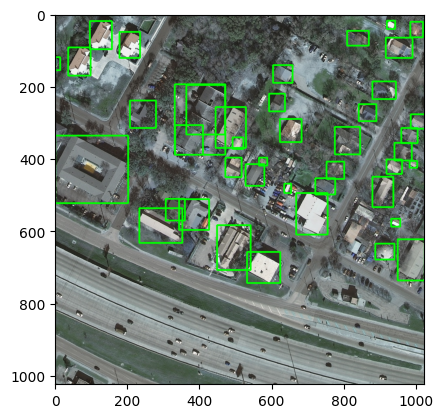

In [11]:
results = yolo_model.predict("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg", device="cuda", conf=0.5)

for result in results:
    boxes = result.boxes.xyxy.cpu().numpy() 

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [12]:
from generate_isolated_masks import generate_isolated_mask

In [13]:
from accuracy import compute_metrics

In [14]:
data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
save_results = "results.json"

In [15]:
os.listdir(data_folder)[:2]

['1102.jpg', '2582.jpg']

In [16]:
data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
save_results = "results.json"

results_data = []

for img_name in os.listdir(data_folder)[:2]:
    
    img_path = os.path.join(data_folder, img_name)
    image = cv2.imread(img_path)
    
    yolo_results = yolo_model.predict(img_path, conf=0.5, device="cuda")
    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    
    
    mask_path = os.path.join(mask_folder, img_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.from_numpy(gt_mask).to("cuda")  # Convert to torch tensor on GPU
    
    sam_predictor.set_image(image)
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        isolated_mask = generate_isolated_mask(gt_mask, [x1, y1, x2, y2])
        
        masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
            
        pred_mask = masks[0]
        pred_mask = torch.from_numpy(masks[0]).to("cuda")  # Convert SAM output to torch tensor on GPU
        
        # print(isolated_mask.size(), pred_mask.size())
        # pred_mask_resized = cv2.resize(pred_mask.astype(np.uint8), (gt_mask.shape[1], gt_mask.shape[0]))

        metrics = compute_metrics(pred_mask, isolated_mask)

        results_data.append(metrics)
    
    

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1102.jpg: 1024x1024 116 0s, 9.0ms
Speed: 3.3ms preprocess, 9.0ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2582.jpg: 1024x1024 (no detections), 9.2ms
Speed: 3.1ms preprocess, 9.2ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 1024)


In [17]:
import pandas as pd

In [18]:
metrics_df = pd.DataFrame(results_data, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall", "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])
metrics_df

,pixel_iou,pixel_dice,pixel_accuracy,pixel_precision,pixel_recall,region_iou,region_dice,region_precision,region_recall,region_success_accuracy
0,0.885881,0.939488,0.999795,0.924654,0.954805,0.885881,0.939488,0.924654,0.954805,1.0
1,0.864611,0.927390,0.999807,0.907811,0.947832,0.864611,0.927390,0.907811,0.947832,1.0
2,0.899656,0.947178,0.999833,0.905366,0.993038,0.899656,0.947178,0.905366,0.993038,1.0
3,0.856960,0.922971,0.999786,0.904313,0.942416,0.856960,0.922971,0.904313,0.942416,1.0
4,0.817610,0.899654,0.999723,0.819156,0.997698,0.817610,0.899654,0.819156,0.997698,1.0
...,...,...,...,...,...,...,...,...,...,...
111,0.774177,0.872717,0.998285,0.790155,0.974545,0.774177,0.872717,0.790155,0.974545,1.0
112,0.703407,0.825882,0.999859,0.737395,0.938503,0.703407,0.825882,0.737395,0.938503,1.0
113,0.826620,0.905081,0.999906,0.855072,0.961303,0.826620,0.905081,0.855072,0.961303,1.0
114,0.788660,0.881844,0.999883,0.827027,0.944444,0.788660,0.881844,0.827027,0.944444,1.0


## FINAL CODE

In [2]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 

from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask

In [4]:
# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/yolo_v12/yolov12/runs/detect/train4/weights/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
csv_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/validation_results_1.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

results_data = []

for img_name in os.listdir(data_folder):
    
    img_path = os.path.join(data_folder, img_name)
    image = cv2.imread(img_path)
    
    yolo_results = yolo_model.predict(img_path, conf=0.5, device="cuda")
    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    
    
    mask_path = os.path.join(mask_folder, img_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.from_numpy(gt_mask).to("cuda")  # Convert to torch tensor on GPU
    
    sam_predictor.set_image(image)
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        isolated_mask = generate_isolated_mask(gt_mask, [x1, y1, x2, y2])
        
        masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
            
        pred_mask = masks[0]
        pred_mask = torch.from_numpy(masks[0]).to("cuda") 
        metrics = compute_metrics(pred_mask, isolated_mask)

        results_data.append(metrics)
        
metrics_df = pd.DataFrame(results_data, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall", "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])
metrics_df.to_csv(csv_path, index=False)


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1102.jpg: 1024x1024 116 0s, 8.6ms
Speed: 6.8ms preprocess, 8.6ms inference, 82.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2582.jpg: 1024x1024 (no detections), 9.2ms
Speed: 3.0ms preprocess, 9.2ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/557.jpg: 1024x1024 79 0s, 8.5ms
Speed: 2.0ms preprocess, 8.5ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/787.jpg: 1024x1024 10 0s, 8.7ms
Speed: 2.1ms preprocess, 8.7ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2012.jpg: 1024x1024 24 0s, 9.1ms
Speed: 3.1ms 

In [6]:
len(os.listdir(data_folder))

576

In [7]:
metrics_df.head(5)

,pixel_iou,pixel_dice,pixel_accuracy,pixel_precision,pixel_recall,region_iou,region_dice,region_precision,region_recall,region_success_accuracy
0,0.885881,0.939488,0.999795,0.924654,0.954805,0.885881,0.939488,0.924654,0.954805,1.0
1,0.864611,0.927390,0.999807,0.907811,0.947832,0.864611,0.927390,0.907811,0.947832,1.0
2,0.899656,0.947178,0.999833,0.905366,0.993038,0.899656,0.947178,0.905366,0.993038,1.0
3,0.856960,0.922971,0.999786,0.904313,0.942416,0.856960,0.922971,0.904313,0.942416,1.0
4,0.817610,0.899654,0.999723,0.819156,0.997698,0.817610,0.899654,0.819156,0.997698,1.0


### This is for YOLO v12 + SAM

In [5]:
metrics_df.mean()

pixel_iou                  0.780119
pixel_dice                 0.863200
pixel_accuracy             0.998868
pixel_precision            0.855653
pixel_recall               0.904678
region_iou                 0.780119
region_dice                0.863200
region_precision           0.855653
region_recall              0.904678
region_success_accuracy    0.964625
dtype: float64

### lets test for single image as whole.


0: 1024x1024 42 0s, 8.0ms
Speed: 14.8ms preprocess, 8.0ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


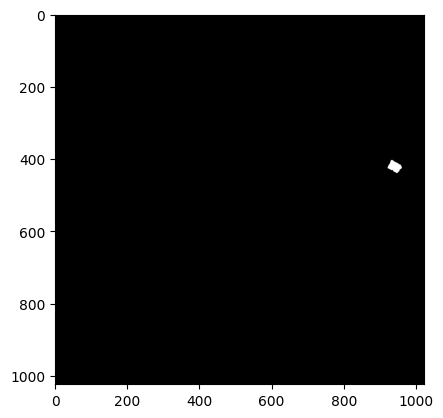

In [40]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt 



# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/yolo_v12/yolov12/runs/detect/train4/weights/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)


test_image = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg")
yolo_results = yolo_model.predict(test_image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(len(boxes))
sam_predictor.set_image(test_image)
masks, _, _ = sam_predictor.predict(box=boxes[3])
masks
plt.imshow(masks[0], cmap="gray")


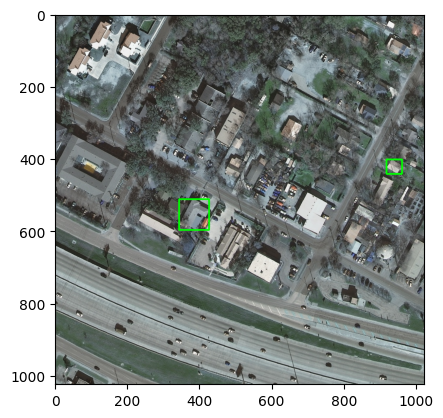

In [43]:
cv2.rectangle(test_image, (int(boxes[3][0]), int(boxes[3][1])), (int(boxes[3][2]), int(boxes[3][3])), (0, 255, 0), 3)
plt.imshow(test_image[:,:,::-1])

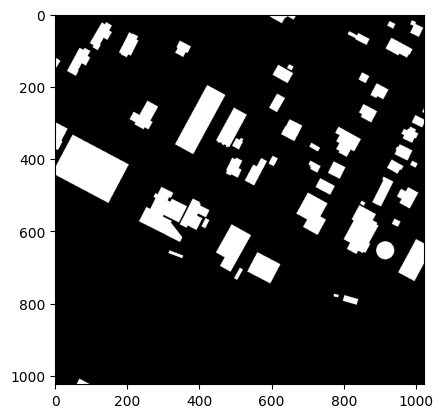

In [42]:
original_mask = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/1.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(original_mask, cmap="gray")


0: 480x1024 2 0s, 8.4ms
Speed: 1.7ms preprocess, 8.4ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 1024)
2


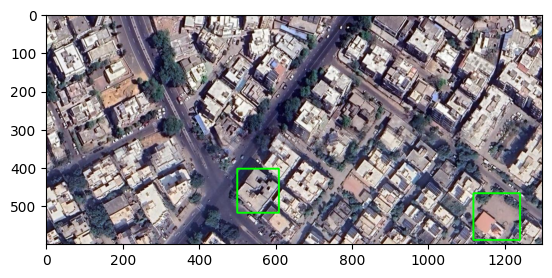

In [45]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt 



# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/yolo_v12/yolov12/runs/detect/train4/weights/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)


test_image = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/sample_1.jpg")
yolo_results = yolo_model.predict(test_image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
print(len(boxes))
sam_predictor.set_image(test_image)

demo = test_image.copy()
for i in boxes:
    cv2.rectangle(demo, (int(i[0]), int(i[1])), (int(i[2]), int(i[3])), (0, 255, 0), 3)

plt.imshow(demo[:,:,::-1])

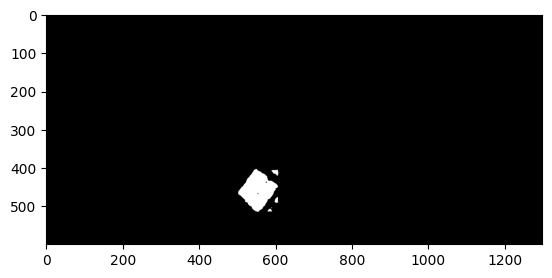

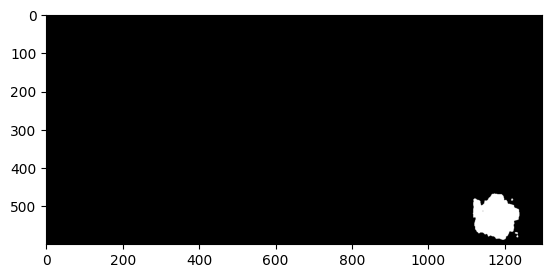

In [46]:
for i in boxes:
    masks, _, _ = sam_predictor.predict(box=i)
    plt.imshow(masks[0], cmap="gray")
    plt.show()

### This is for YOLO v9 +SAM

In [1]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 

from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask

In [2]:
import os 

os.getcwd()

'/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection'

In [3]:
os.chdir("/home/selc-a4-sr2/yolov9")

In [4]:
os.getcwd()

'/home/selc-a4-sr2/yolov9'

In [5]:
from models.common import DetectMultiBackend
from utils.torch_utils import select_device

device = select_device()
yolo_model = DetectMultiBackend('/home/selc-a4-sr2/yolov9/runs/train/exp6/weights/best.pt', device)


YOLOv5 🚀 1e33dbb Python-3.12.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48539MiB)

Fusing layers... 
gelan-c summary: 467 layers, 25411731 parameters, 0 gradients, 102.5 GFLOPs


In [7]:
# Load YOLO model 
# yolo_model = YOLO("/home/selc-a4-sr2/yolov9/runs/train/exp6/weights/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
csv_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/Yolo_v9_validation_results_1.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

results_data = []

for img_name in os.listdir(data_folder):
    
    img_path = os.path.join(data_folder, img_name)
    image = cv2.imread(img_path)
    
    yolo_results = yolo_model.predict(img_path, conf=0.5, device="cuda")
    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    
    
    mask_path = os.path.join(mask_folder, img_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.from_numpy(gt_mask).to("cuda")  # Convert to torch tensor on GPU
    
    sam_predictor.set_image(image)
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        isolated_mask = generate_isolated_mask(gt_mask, [x1, y1, x2, y2])
        
        masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
            
        pred_mask = masks[0]
        pred_mask = torch.from_numpy(masks[0]).to("cuda") 
        metrics = compute_metrics(pred_mask, isolated_mask)

        results_data.append(metrics)
        
metrics_df = pd.DataFrame(results_data, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall", "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])
metrics_df.to_csv(csv_path, index=False)

AttributeError: 'DetectMultiBackend' object has no attribute 'predict'